## 1 - INSTALACION Y DEPENDENCIAS

In [ ]:
pip install fitter

In [ ]:
from fitter import Fitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2 - VALIDACION CSV

In [ ]:
# Ruta al CSV dentro de Drive
RUTA_CSV = '/content/drive/MyDrive/pedidos_delivery.csv'

df_delivery = pd.read_csv(RUTA_CSV, parse_dates=['fecha_hora'])
print(f'Registros cargados : {len(df_delivery):,}')
print(f'Columnas           : {df_delivery.columns.tolist()}')
print(f'Período            : {df_delivery["fecha_hora"].min()} → {df_delivery["fecha_hora"].max()}')
df_delivery.head(10)

Registros cargados : 5,686
Columnas           : ['id_pedido', 'fecha_hora', 'zona_destino', 'distancia_km', 'valor_pedido', 'clima', 'dia_semana', 'prioridad']
Período            : 2024-03-01 00:19:06 → 2024-04-29 23:31:16


,id_pedido,fecha_hora,zona_destino,distancia_km,valor_pedido,clima,dia_semana,prioridad
0,1,2024-03-01 00:19:06,Parque Centenario,1.26,18700,normal,viernes,normal
1,2,2024-03-01 00:27:42,Colegiales,1.80,14800,normal,viernes,express
2,3,2024-03-01 00:32:47,Colegiales,2.10,7000,normal,viernes,normal
3,4,2024-03-01 00:35:44,Caballito,2.52,18500,normal,viernes,normal
4,5,2024-03-01 00:38:16,Villa Crespo,0.49,10200,normal,viernes,normal
5,6,2024-03-01 00:42:43,Almagro,1.03,23100,normal,viernes,normal
6,7,2024-03-01 00:47:36,Once,1.62,20200,normal,viernes,normal
7,8,2024-03-01 00:53:44,Villa Ortuzar,1.18,9200,normal,viernes,express
8,9,2024-03-01 01:02:19,Palermo,2.33,12100,normal,viernes,normal
9,10,2024-03-01 01:24:45,Parque Centenario,1.17,20300,normal,viernes,express


# 3 - Transformacion datos

In [ ]:
# Transformacion fecha a datetime
df_delivery['fecha_hora_datetime'] = pd.to_datetime(df_delivery['fecha_hora'])


# Calculo intervalo entre arribos
df_delivery['IA'] = df_delivery['fecha_hora_datetime'].diff()
df_delivery['IA_segundos'] = df_delivery['IA'].dt.total_seconds()
df_delivery['IA_minutos']  = df_delivery['IA_segundos'] / 60

# Calculo velocidad
VELOCIDAD_KMH = 18
df_delivery['TA_minutos'] = ((df_delivery['distancia_km'] / VELOCIDAD_KMH) * 60) * 2

### IA según horario

In [ ]:
# Obtener hora
df_delivery['hora'] = df_delivery['fecha_hora_datetime'].dt.hour

# Separar por horario
df_manana = df_delivery[(df_delivery['hora'] >= 9) & (df_delivery['hora'] < 12)].copy()

df_mediodia = df_delivery[(df_delivery['hora'] >= 12) & (df_delivery['hora'] < 16)].copy()

df_tarde = df_delivery[(df_delivery['hora'] >= 16) & (df_delivery['hora'] < 20)].copy()

df_noche = df_delivery[(df_delivery['hora'] >= 20) | (df_delivery['hora'] < 2)].copy()

# Calculo intervalo entre arrivos para cada uno
df_manana['IA'] = df_manana['fecha_hora_datetime'].diff()
df_manana['IA_segundos'] = df_manana['IA'].dt.total_seconds()
df_manana['IA_minutos']  = df_manana['IA_segundos'] / 60

df_mediodia['IA'] = df_mediodia['fecha_hora_datetime'].diff()
df_mediodia['IA_segundos'] = df_mediodia['IA'].dt.total_seconds()
df_mediodia['IA_minutos']  = df_mediodia['IA_segundos'] / 60

df_tarde['IA'] = df_tarde['fecha_hora_datetime'].diff()
df_tarde['IA_segundos'] = df_tarde['IA'].dt.total_seconds()
df_tarde['IA_minutos']  = df_tarde['IA_segundos'] / 60

df_noche['IA'] = df_noche['fecha_hora_datetime'].diff()
df_noche['IA_segundos'] = df_noche['IA'].dt.total_seconds()
df_noche['IA_minutos']  = df_noche['IA_segundos'] / 60

# 4 - Filtro TA e IA

In [ ]:
histograma_TA_amplio = df_delivery[df_delivery['TA_minutos'] > 2]
histograma_TA_primer_minuto = df_delivery[df_delivery['TA_minutos'] <= 2]
histograma_IA = df_delivery[df_delivery['IA_minutos'] < 60]

In [ ]:
histograma_IA_manana = df_manana[df_manana['IA_minutos'] < 60]
histograma_IA_mediodia = df_mediodia[df_mediodia['IA_minutos'] < 60]
histograma_IA_tarde = df_tarde[df_tarde['IA_minutos'] < 60]
histograma_IA_noche = df_noche[df_noche['IA_minutos'] < 60]

# 5 - Histogramas

array([[<Axes: title={'center': 'valor_pedido'}>]], dtype=object)

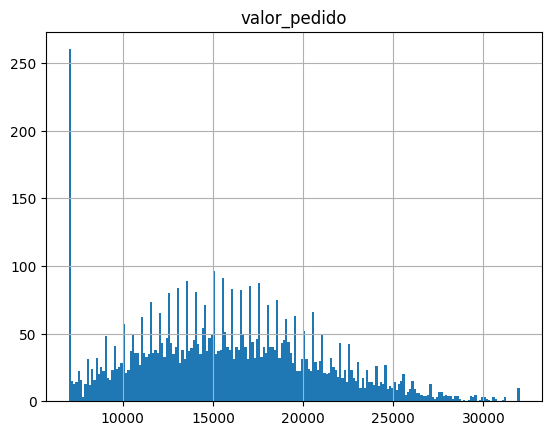

In [ ]:
df_delivery.hist('valor_pedido', bins=200)

array([[<Axes: title={'center': 'TA_minutos'}>]], dtype=object)

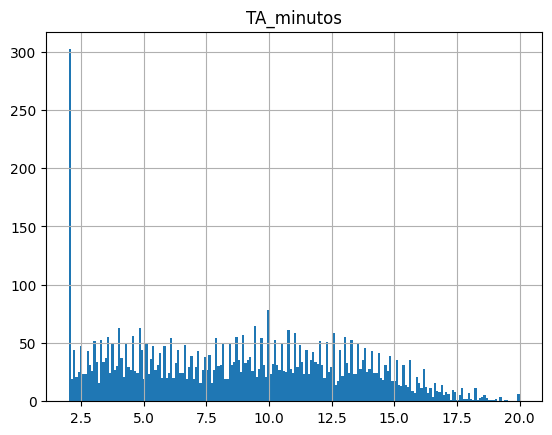

In [ ]:
df_delivery.hist('TA_minutos', bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

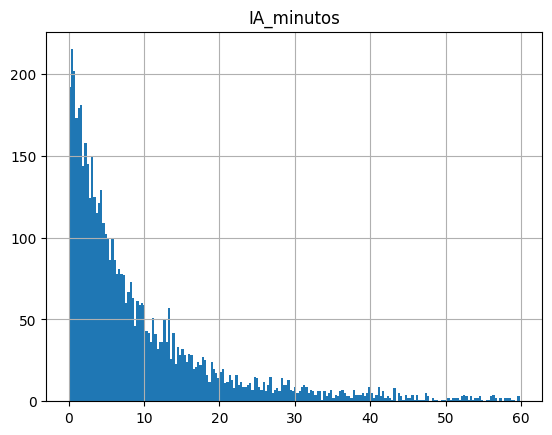

In [ ]:
histograma_IA.hist('IA_minutos', bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

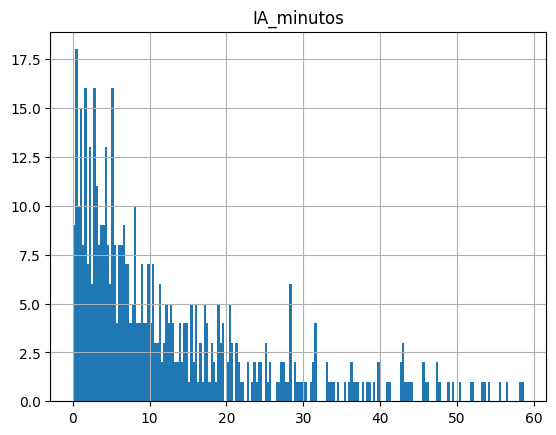

In [ ]:
histograma_IA_manana.hist('IA_minutos',bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

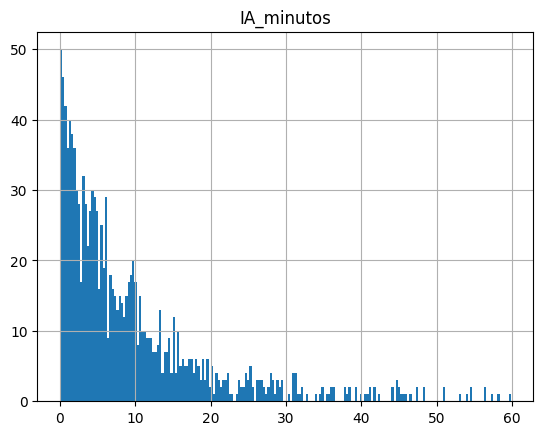

In [ ]:
histograma_IA_mediodia.hist('IA_minutos',bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

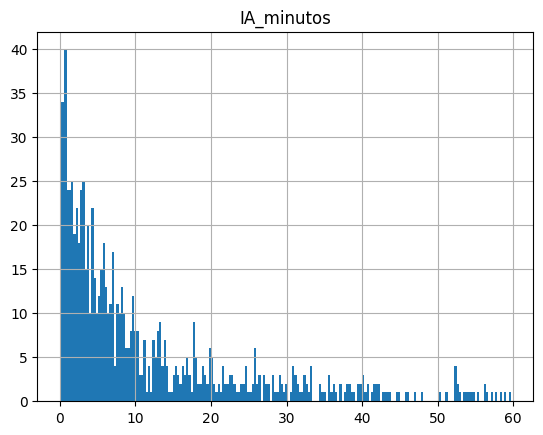

In [ ]:
histograma_IA_tarde.hist('IA_minutos',bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

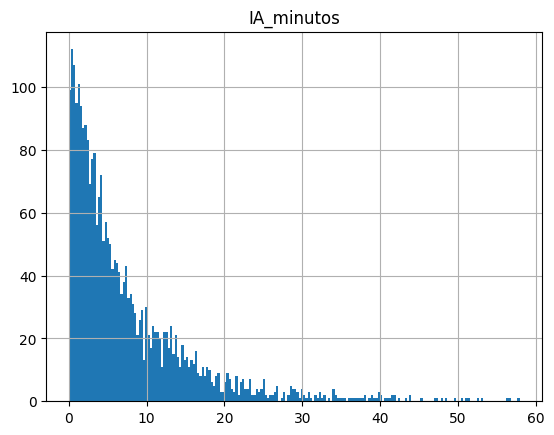

In [ ]:
histograma_IA_noche.hist('IA_minutos',bins=200)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
rice,4.133246e-08,112809.502985,112829.440272,0.074265,0.029101,1.286767e-04
rdist,4.194704e-08,113132.375514,113152.312801,0.068701,0.039100,5.456299e-08
ncx2,4.195312e-08,113067.162454,113093.745503,0.072432,0.033476,5.694943e-06
tukeylambda,4.195985e-08,113137.254065,113157.191352,0.068699,0.039598,3.491827e-08
recipinvgauss,4.203864e-08,113117.625449,113137.562736,0.071308,NaN,NaN
gennorm,4.207879e-08,113120.450523,113140.387810,0.069475,0.037176,2.902953e-07
weibull_min,4.208431e-08,112849.496688,112869.433974,0.077912,0.028967,1.405831e-04
maxwell,4.218913e-08,112910.413599,112923.705124,0.077606,0.025786,1.021412e-03
norm,4.221457e-08,113160.489512,113173.781036,0.070870,0.041646,5.249480e-09
t,4.221457e-08,113162.489856,113182.427142,0.070870,0.041646,5.249379e-09


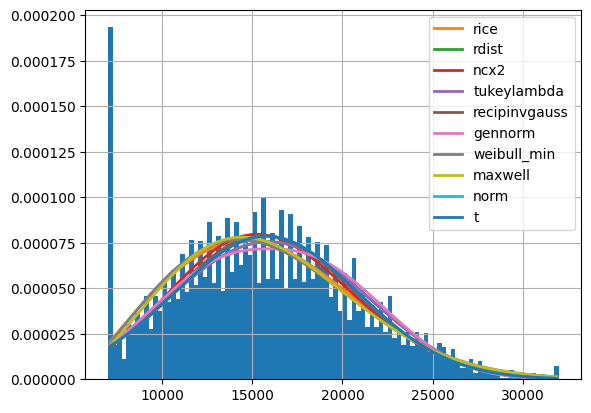

In [ ]:
fdp_VP = Fitter(df_delivery.valor_pedido)
fdp_VP.fit()
fdp_VP.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
gausshyper,0.050499,25148.049092,25187.923666,0.118114,0.056546,3.038536e-16
gengamma,0.057003,29401.052418,29427.635467,0.086118,0.049845,1.022720e-12
mielke,0.059239,29180.297338,29206.880387,0.052753,0.049420,1.654270e-12
exponweib,0.062252,28709.719486,28736.302536,0.102770,0.049420,1.654270e-12
kappa4,0.073156,29387.099582,29413.682631,0.159847,0.072878,1.045369e-26
kappa3,0.073839,31152.816209,31172.753496,0.057066,0.049420,1.654270e-12
halfgennorm,0.074134,31148.734840,31168.672127,0.056736,0.049420,1.654270e-12
genpareto,0.079983,31439.015155,31458.952442,0.115983,0.052268,6.107215e-14
beta,0.081930,27917.417960,27944.001009,0.131336,0.130261,1.401200e-84
genhalflogistic,0.082060,31326.701819,31346.639106,0.082140,0.049420,1.654270e-12


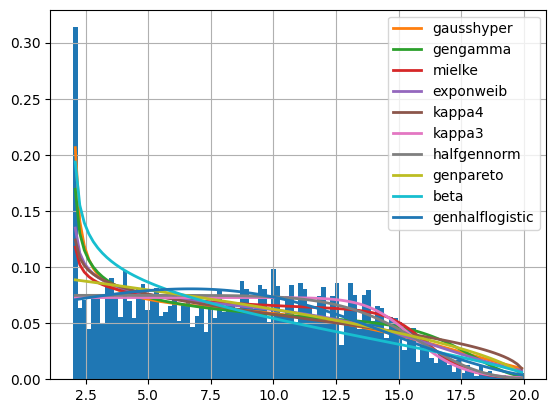

In [ ]:
fdp_TA = Fitter(df_delivery.TA_minutos)
fdp_TA.fit()
fdp_TA.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
betaprime,0.000394,35273.214652,35299.645711,0.009680,0.010444,0.585388
burr12,0.000430,35261.549168,35287.980228,0.010366,0.012468,0.359493
pareto,0.000431,35288.701885,35308.525180,0.010315,0.013065,0.304832
halfgennorm,0.000437,35267.159359,35286.982654,0.010109,0.011280,0.485552
truncpareto,0.000586,35214.236966,35240.668025,0.010466,0.022343,0.008333
burr,0.000695,35341.634603,35368.065663,0.012165,0.020853,0.016881
weibull_min,0.000717,35200.803612,35220.626907,0.012080,0.019318,0.033187
recipinvgauss,0.000819,35312.170605,35331.993900,0.010515,0.020650,0.018510
geninvgauss,0.000823,35288.923355,35315.354414,0.012016,0.015951,0.122031
chi2,0.000884,35257.508602,35277.331897,0.014587,0.027953,0.000378


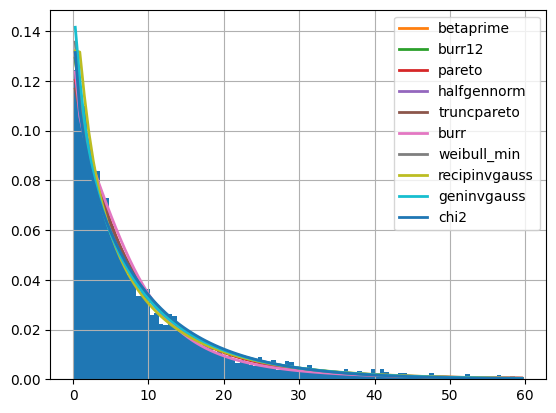

In [ ]:
fdp_IA = Fitter(histograma_IA.IA_minutos)
fdp_IA.fit()
fdp_IA.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
truncpareto,0.002804,3645.553824,3662.553725,0.645862,0.019837,0.984538
burr12,0.002924,3667.917051,3684.916952,0.499147,0.030184,0.720976
geninvgauss,0.002943,3665.200178,3682.200079,0.520217,0.023690,0.926515
f,0.002954,3667.259006,3684.258907,0.521338,0.026321,0.856005
halfgennorm,0.002961,3665.703494,3678.453420,0.515704,0.026133,0.861744
ncf,0.002978,3672.959322,3694.209198,0.489332,0.031859,0.657060
exponweib,0.002987,3664.858588,3681.858489,0.519655,0.025945,0.867418
gengamma,0.002989,3664.836890,3681.836791,0.522565,0.026485,0.850892
genhyperbolic,0.002996,3666.874600,3688.124476,0.520121,0.023604,0.928415
gamma,0.003030,3660.864897,3673.614823,0.510902,0.028849,0.770444


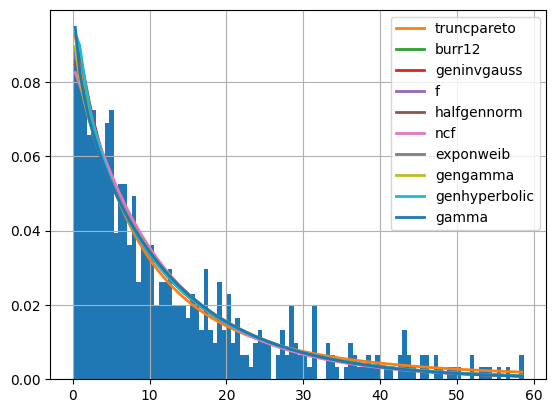

In [ ]:
fdp_IA_manana = Fitter(histograma_IA_manana.IA_minutos)
fdp_IA_manana.fit()
fdp_IA_manana.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
betaprime,0.001663,7871.026561,7891.452986,0.190344,0.013774,0.972319
gengamma,0.001681,7863.681024,7884.107449,0.190936,0.017959,0.819339
weibull_min,0.001687,7863.248428,7878.568246,0.187504,0.017896,0.822577
chi2,0.001703,7869.580566,7884.900385,0.179580,0.020115,0.699050
burr12,0.001703,7872.262950,7892.689375,0.196816,0.013817,0.971506
halfgennorm,0.001708,7870.937277,7886.257096,0.195734,0.015271,0.934301
geninvgauss,0.001725,7872.091231,7892.517656,0.185767,0.021639,0.609458
gamma,0.001732,7863.469691,7878.789510,0.181996,0.022997,0.531215
genhyperbolic,0.001746,7878.646265,7904.179296,0.189874,0.021486,0.618415
burr,0.001801,7895.489947,7915.916371,0.221909,0.027542,0.307341


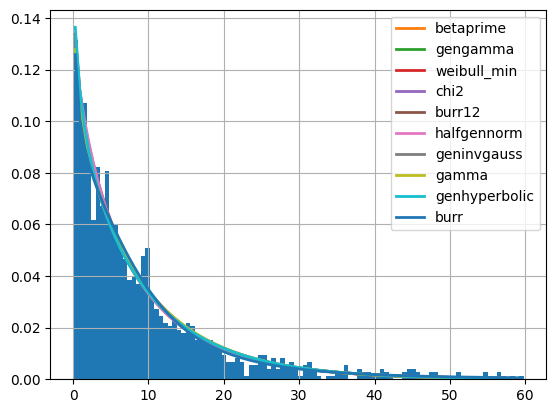

In [ ]:
fdp_IA_mediodia = Fitter(histograma_IA_mediodia.IA_minutos)
fdp_IA_mediodia.fit()
fdp_IA_mediodia.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
betaprime,0.002577,5872.054733,5891.091754,0.181534,0.028784,0.464258
burr12,0.002761,5859.334992,5878.372013,0.177063,0.032439,0.317691
dpareto_lognorm,0.002798,5868.780341,5897.335872,0.171001,0.039798,0.126879
mielke,0.002922,5895.632963,5914.669985,0.159448,0.061942,0.002562
weibull_min,0.002954,5825.372028,5839.649794,0.181048,0.031453,0.353829
johnsonsb,0.003031,5834.620138,5853.657159,0.251958,0.028569,0.473870
genpareto,0.003119,5974.326482,5988.604247,0.229201,0.086433,0.000005
gamma,0.003126,5838.542029,5852.819794,0.156747,0.057046,0.007029
geninvgauss,0.003177,5864.251951,5883.288972,0.188639,0.029405,0.436997
burr,0.003262,5873.266454,5892.303475,0.171871,0.040433,0.116171


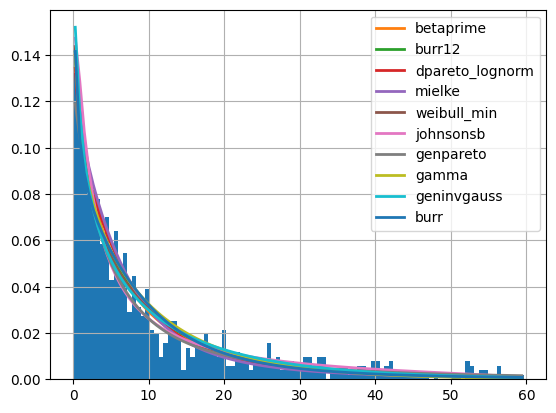

In [ ]:
fdp_IA_tarde = Fitter(histograma_IA_tarde.IA_minutos)
fdp_IA_tarde.fit()
fdp_IA_tarde.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
exponweib,0.000593,16217.915118,16241.517664,0.044291,0.009816,0.954927
pareto,0.000635,16217.448999,16235.150908,0.044895,0.012336,0.801140
lomax,0.000635,16217.449157,16235.151067,0.044942,0.012346,0.800387
truncpareto,0.000643,16209.037396,16232.639942,0.046130,0.013820,0.675790
burr12,0.000673,16217.237272,16240.839819,0.043809,0.011581,0.857818
betaprime,0.000680,16218.645963,16242.248510,0.043753,0.012549,0.784004
halfgennorm,0.000811,16217.719141,16235.421051,0.042400,0.014664,0.601958
powerlognorm,0.000916,16251.596817,16275.199364,0.055934,0.023480,0.100399
chi2,0.000973,16240.776403,16258.478313,0.030511,0.027949,0.028943
gengamma,0.001001,16192.043278,16215.645825,0.037445,0.017070,0.406664


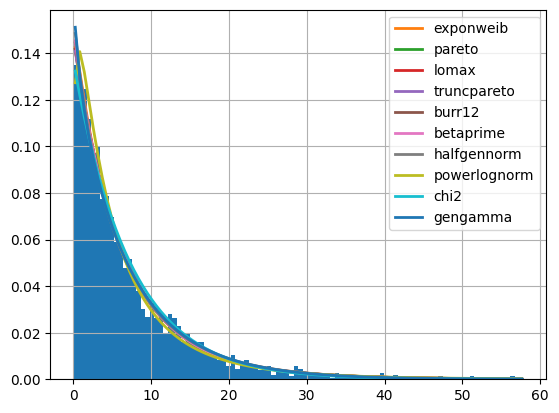

In [ ]:
fdp_IA_noche = Fitter(histograma_IA_noche.IA_minutos)
fdp_IA_noche.fit()
fdp_IA_noche.summary(10)

In [ ]:
fdp_VP.get_best(method = 'sumsquare_error')

{'rice': {'b': np.float64(1.2333012433636572),
  'loc': np.float64(5423.195159896445),
  'scale': np.float64(6147.806584164133)}}

In [ ]:
b = np.float64(1.2333012433636572)
loc = np.float64(5423.195159896445)
scale = np.float64(6147.806584164133)

In [ ]:
fdp_VP_rice = stats.rice.rvs(b=b,loc=loc,scale=scale,size=12000)

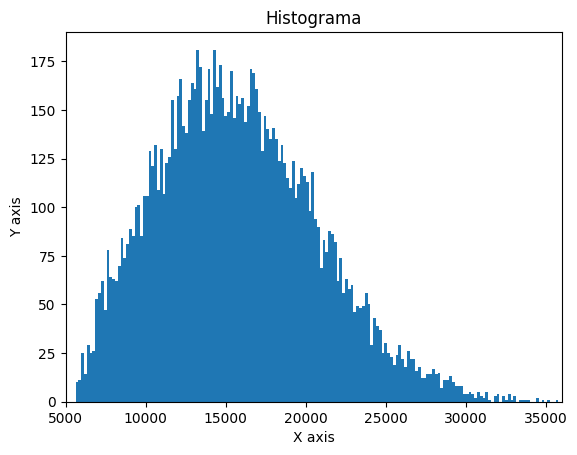

In [ ]:
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(5000,36000)
#plt.ylim(0,1300)
plt.hist(fdp_VP_rice, bins=200)
plt.show()

In [ ]:
fdp_TA.get_best(method = 'sumsquare_error')

{'gausshyper': {'a': np.float64(0.6400351082272648),
  'b': np.float64(3.291445952123444),
  'c': np.float64(-21.641630779133074),
  'z': np.float64(0.18368453258021916),
  'loc': np.float64(1.999999999999997),
  'scale': np.float64(21.199830239869726)}}

In [ ]:
a = np.float64(0.6400351082272648)
b = np.float64(3.291445952123444)
c = np.float64(-21.641630779133074)
z = np.float64(0.18368453258021916)
loc = np.float64(1.999999999999997)
scale = np.float64(21.199830239869726)

In [ ]:
fdp_TA_gausshyper = stats.gausshyper.rvs(a=a, b=b, c=c, z=z, loc=loc, scale=scale, size=15000)

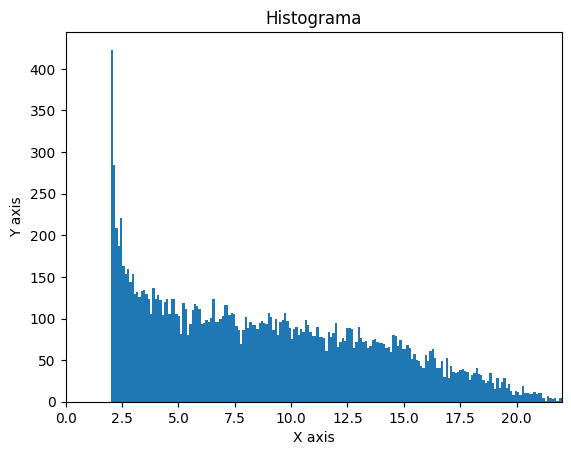

In [ ]:
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,22)
#plt.ylim(0,1300)
plt.hist(fdp_TA_gausshyper, bins=200)
plt.show()

In [ ]:
fdp_IA.get_best(method = 'sumsquare_error')

{'betaprime': {'a': np.float64(0.9530134056313297),
  'b': np.float64(6.943339473955428),
  'loc': np.float64(-6.808893876682824e-12),
  'scale': np.float64(58.466567743807836)}}

In [ ]:
a = np.float64(0.9530134056313297)
b = np.float64(6.943339473955428)
loc= np.float64(-6.808893876682824e-12)
scale = np.float64(58.466567743807836)

In [ ]:
fdp_IA_betaprime = stats.betaprime.rvs(a,b,loc=loc,scale=scale,size=15000)

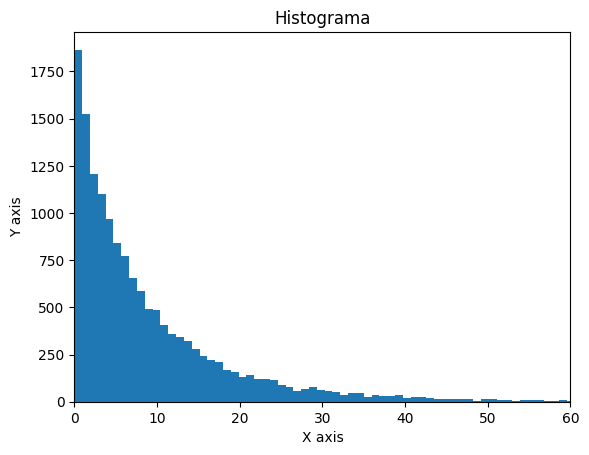

In [ ]:
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
#plt.ylim(0,1300)
plt.hist(fdp_IA_betaprime, bins=200)
plt.show()

fdp mañana

In [ ]:
fdp_IA_manana.get_best(method = 'sumsquare_error')

{'truncpareto': {'b': np.float64(2.2551978138264284),
  'c': np.float64(3.327098109232383),
  'loc': -25.222206202645722,
  'scale': np.float64(25.238872869312388)}}

In [ ]:
b = np.float64(2.2551978138264284)
c = np.float64(3.327098109232383)
loc = -25.222206202645722
scale = np.float64(25.238872869312388)

In [ ]:
fdp_IA_manana_truncpareto = stats.truncpareto.rvs(b,c,loc=loc,scale=scale,size=15000)

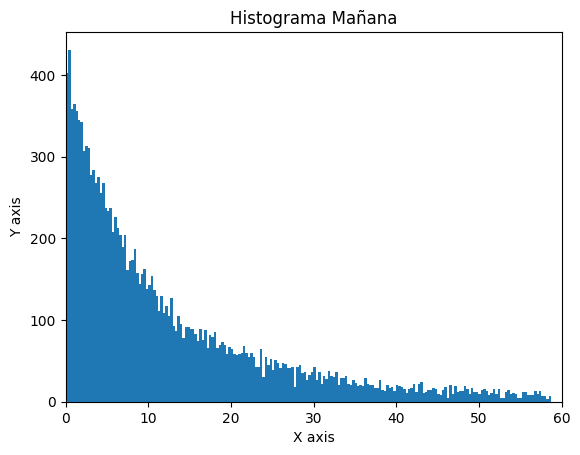

In [ ]:
plt.title("Histograma Mañana")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
#plt.ylim(0,1300)
plt.hist(fdp_IA_manana_truncpareto, bins=200)
plt.show()

fdp mediodia

In [ ]:
fdp_IA_mediodia.get_best(method = 'sumsquare_error')

{'betaprime': {'a': np.float64(0.932081706240188),
  'b': np.float64(12.90213366815335),
  'loc': np.float64(-7.211798797808576e-15),
  'scale': np.float64(118.81550086970424)}}

In [ ]:
a = np.float64(0.932081706240188)
b = np.float64(12.90213366815335)
loc = np.float64(-7.211798797808576e-15)
scale = np.float64(118.81550086970424)

In [ ]:
fdp_IA_mediodia_betaprime = stats.betaprime.rvs(a,b,loc=loc,scale=scale,size=15000)

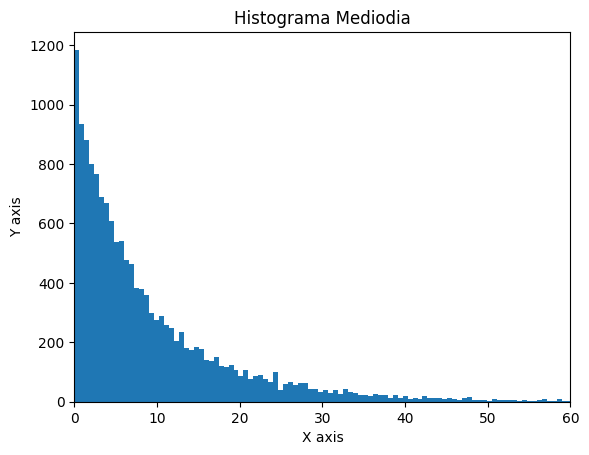

In [ ]:
plt.title("Histograma Mediodia")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
#plt.ylim(0,1300)
plt.hist(fdp_IA_mediodia_betaprime, bins=200)
plt.show()

fdp tarde

In [ ]:
fdp_IA_tarde.get_best(method = 'sumsquare_error')

{'betaprime': {'a': np.float64(0.8786906483738385),
  'b': np.float64(2.8851477922498807),
  'loc': np.float64(-2.1062865154599568e-16),
  'scale': np.float64(27.190131073332147)}}

In [ ]:
a = np.float64(0.8786906483738385)
b = np.float64(2.8851477922498807)
loc = np.float64(-2.1062865154599568e-16)
scale = np.float64(27.190131073332147)

In [ ]:
fdp_IA_tarde_betaprime = stats.betaprime.rvs(a,b,loc=loc,scale=scale,size=15000)

In [ ]:
plt.title("Histograma Tarde")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
plt.ylim(0,1200)
plt.hist(fdp_IA_tarde_betaprime, bins=200)
plt.show()

NameError: name 'plt' is not defined

fdp noche

In [ ]:
fdp_IA_noche.get_best(method = 'sumsquare_error')

{'exponweib': {'a': np.float64(1.314914115028272),
  'c': np.float64(0.8132275635917063),
  'loc': np.float64(-0.0009800860801003194),
  'scale': np.float64(5.506134922219468)}}

In [ ]:
a = np.float64(1.314914115028272)
c = np.float64(0.8132275635917063)
loc = np.float64(-0.0009800860801003194)
scale = np.float64(5.506134922219468)

In [ ]:
fdp_IA_noche_exponweib = stats.exponweib.rvs(a,c,loc=loc,scale=scale,size=15000)

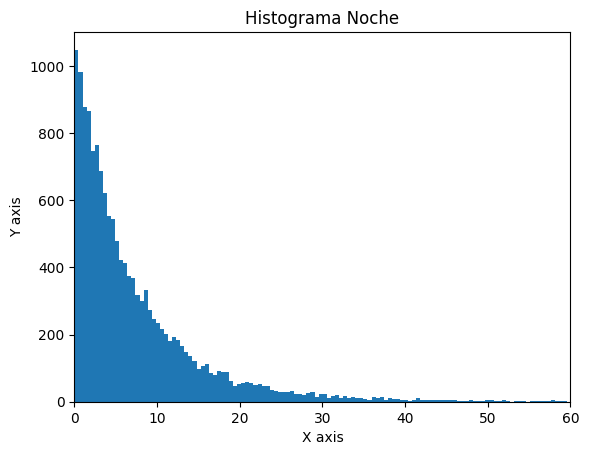

In [ ]:
plt.title("Histograma Noche")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
#plt.ylim(0,1300)
plt.hist(fdp_IA_noche_exponweib, bins=200)
plt.show()